# 📊 Signal Scenario Analysis Framework

This notebook demonstrates comprehensive signal analysis for different scenarios using reusable analysis functions:

## 🎯 Signal Scenarios
1. **Main Signal Only** - Single source baseline
2. **Main + 1 Interference** - Two-source interference scenario  
3. **Main + 2 Interferences** - Three-source interference scenario
4. **Main + 1 Multipath** - Single source with multipath effects
5. **Main + 2 Multipath** - Single source with multiple multipath components
6. **Main + 1 Interference + 1 Multipath** - Complex scenario with both interference and multipath

## 🔧 Analysis Functions
Each scenario will be analyzed using standardized functions for:
- **Time Domain Analysis** - Signal waveforms and statistics
- **Frequency Domain Analysis** - Power spectral density
- **Correlation Analysis** - Cross-correlation between sources
- **Statistical Summary** - Key signal parameters and metrics


In [14]:
# Import required modules
import sys
sys.path.append('../src')
from signalgen.signal_generator import SignalConfig, SignalGenerator
from visualization.signal_plotting import plot_signal_analysis, plot_autocorrelation, plot_crosscorrelation, analyze_correlation
import matplotlib.pyplot as plt
import numpy as np
# Set up matplotlib for better plots - adjusted for screen fitting
plt.rcParams['figure.figsize'] = (10, 6)  # Reduced from (15, 10) for better screen fit
plt.rcParams['font.size'] = 10  # Slightly smaller font
plt.rcParams['figure.dpi'] = 100  # Standard DPI for better display
plt.rcParams['figure.max_open_warning'] = 20  # Allow more figures

# Enable interactive matplotlib backend for Jupyter notebooks
%matplotlib widget



print("✅ Imports successful! Testing improved SignalGenerator...")

✅ Imports successful! Testing improved SignalGenerator...


In [ ]:
# 🔧 Analysis Functions

import scipy.signal


print("🔧 Analysis functions loaded successfully!")
print("📋 Available functions:")
print("  - analyze_time_domain(signals, t, title)")
print("  - analyze_frequency_domain(signals, fs, title)")
print("  - analyze_correlation(signals, title)")
print("  - compute_statistics(signals, fs, title)")
print("  - full_signal_analysis(signals, t, fs, title)")


🔧 Analysis functions loaded successfully!
📋 Available functions:
  - analyze_time_domain(signals, t, title)
  - analyze_frequency_domain(signals, fs, title)
  - analyze_correlation(signals, title)
  - compute_statistics(signals, fs, title)
  - full_signal_analysis(signals, t, fs, title)


In [16]:
# 🎯 Signal Scenario Generation

# Create time vector for all scenarios
fs = 1e6  # 1 MHz sampling rate
T = 1024  # 1000 samples
t = np.arange(T) / fs

# Common parameters
freq_main = 100e3  # Main signal frequency
freq_interference1 = 150e3  # First interference frequency
freq_interference2 = 200e3  # Second interference frequency

print(f"📊 Time vector: {T} samples at {fs/1e6:.1f} MHz ({T/fs*1e6:.1f} μs duration)")
print(f"🎯 Main frequency: {freq_main/1e3:.1f} kHz")
print(f"📡 Interference frequencies: {freq_interference1/1e3:.1f} kHz, {freq_interference2/1e3:.1f} kHz")

# ===== 1. Main Signal Only =====
config_main_only = SignalConfig(
    fs=fs,
    T=T,
    num_sources=1,
    angles=[0.0],
    frequencies=[freq_main],
    main_source_power=0,
    use_full_bandwidth=True
)

generator_main_only = SignalGenerator(config_main_only)

# ===== 2. Main + 1 Interference =====
config_main_1_interference = SignalConfig(
    fs=fs,
    T=T,
    num_sources=2,
    angles=[0.0, 60.0],
    frequencies=[freq_main, freq_interference1],
    main_source_power=0,  # Main at 0dB, interference at -6dB
    sir_db=[0],
    use_full_bandwidth=True
)

generator_main_1_interference = SignalGenerator(config_main_1_interference)

# ===== 3. Main + 2 Interferences =====
config_main_2_interference = SignalConfig(
    fs=fs,
    T=T,
    num_sources=3,
    angles=[0.0, 60.0, 120.0],
    frequencies=[freq_main, freq_interference1, freq_interference2],
    main_source_power=0,  # Main at 0dB, interferences at -6dB and -10dB
    sir_db=[0, 0],
    use_full_bandwidth=True
)

generator_main_2_interference = SignalGenerator(config_main_2_interference)

# ===== 4. Main + 1 Multipath =====
config_main_1_mp = SignalConfig(
    fs=fs,
    T=T,
    num_sources=1,
    angles=[0.0],
    frequencies=[freq_main],
    main_source_power=0,
    use_full_bandwidth=True,
    enable_multipath=True
)

generator_main_1_mp = SignalGenerator(config_main_1_mp)

# ===== 5. Main + 2 Multipath =====
config_main_2_mp = SignalConfig(
    fs=fs,
    T=T,
    num_sources=1,
    angles=[0.0],
    frequencies=[freq_main],
    main_source_power=0,
    use_full_bandwidth=True,
    enable_multipath=True
)

generator_main_2_mp = SignalGenerator(config_main_2_mp)

# ===== 6. Main + 1 Interference + 1 Multipath =====
config_main_1_interference_1_mp = SignalConfig(
    fs=fs,
    T=T,
    num_sources=2,
    angles=[0.0, 60.0],
    frequencies=[freq_main, freq_interference1],
    main_source_power=0,
    sir_db=[0],
    use_full_bandwidth=True,
    enable_multipath=True
)

generator_main_1_interference_1_mp = SignalGenerator(config_main_1_interference_1_mp)

print("\n🔧 All signal generators configured successfully!")
print("📋 Configured scenarios:")
print("  1. Main Signal Only")
print("  2. Main + 1 Interference") 
print("  3. Main + 2 Interferences")
print("  4. Main + 1 Multipath")
print("  5. Main + 2 Multipath")
print("  6. Main + 1 Interference + 1 Multipath")


📊 Time vector: 1024 samples at 1.0 MHz (1024.0 μs duration)
🎯 Main frequency: 100.0 kHz
📡 Interference frequencies: 150.0 kHz, 200.0 kHz

🔧 All signal generators configured successfully!
📋 Configured scenarios:
  1. Main Signal Only
  2. Main + 1 Interference
  3. Main + 2 Interferences
  4. Main + 1 Multipath
  5. Main + 2 Multipath
  6. Main + 1 Interference + 1 Multipath


In [17]:
# 🔄 Signal Generation for All Scenarios

# Generate source signals for all scenarios
signals_main_only = generator_main_only.generate_source_signals(t)
signals_main_1_interference = generator_main_1_interference.generate_source_signals(t)
signals_main_2_interference = generator_main_2_interference.generate_source_signals(t)
signals_main_1_mp = generator_main_1_mp.generate_source_signals(t)
signals_main_2_mp = generator_main_2_mp.generate_source_signals(t)
signals_main_1_interference_1_mp = generator_main_1_interference_1_mp.generate_source_signals(t)

print("📊 Generated source signals for all scenarios")
print(f"  Main Only: {signals_main_only.shape}")
print(f"  Main + 1 Interference: {signals_main_1_interference.shape}")
print(f"  Main + 2 Interferences: {signals_main_2_interference.shape}")
print(f"  Main + 1 Multipath: {signals_main_1_mp.shape}")
print(f"  Main + 2 Multipath: {signals_main_2_mp.shape}")
print(f"  Main + 1 Interference + 1 Multipath: {signals_main_1_interference_1_mp.shape}")

# Add multipath effects to multipath scenarios
print("\n🌊 Adding multipath effects...")

# Note: For this demo, we'll simulate multipath by adding delayed and attenuated versions
# In a real implementation, you'd use the generator's add_multipath method

# Scenario 4: Main + 1 Multipath
# Add one multipath component with 0.1 delay and 0.3 attenuation
signals_main_1_mp, _ = generator_main_1_mp.add_multipath(signals_main_1_mp, t, config_main_1_mp.fs, 2.4e9, config_main_1_mp.bandwidth, num_multipath_components=1)

# Scenario 5: Main + 2 Multipath
# Add two multipath components
signals_main_2_mp, _ = generator_main_2_mp.add_multipath(signals_main_2_mp, t, config_main_2_mp.fs, 2.4e9, config_main_2_mp.bandwidth, num_multipath_components=2)

# Scenario 6: Main + 1 Interference + 1 Multipath
# Add multipath to the main signal (first source)
signals_main_1_interference_1_mp, _ = generator_main_1_interference_1_mp.add_multipath(signals_main_1_interference_1_mp, t, config_main_1_interference_1_mp.fs, 2.4e9, config_main_1_interference_1_mp.bandwidth, num_multipath_components=1)


# Store all scenarios in a dictionary for easy access
scenarios = {
    'Main Only': signals_main_only,
    'Main + 1 Interference': signals_main_1_interference,
    'Main + 2 Interferences': signals_main_2_interference,
    'Main + 1 Multipath': signals_main_1_mp,
    'Main + 2 Multipath': signals_main_2_mp,
    'Main + 1 Interference + 1 Multipath': signals_main_1_interference_1_mp
}

print("\n🗂️ All scenarios ready for analysis!")
print("📋 Available scenarios:")
for name, signals in scenarios.items():
    print(f"  {name}: {signals.shape}")


📊 Generated source signals for all scenarios
  Main Only: (1, 1024)
  Main + 1 Interference: (2, 1024)
  Main + 2 Interferences: (3, 1024)
  Main + 1 Multipath: (1, 1025)
  Main + 2 Multipath: (1, 1025)
  Main + 1 Interference + 1 Multipath: (2, 1025)

🌊 Adding multipath effects...

🗂️ All scenarios ready for analysis!
📋 Available scenarios:
  Main Only: (1, 1024)
  Main + 1 Interference: (2, 1024)
  Main + 2 Interferences: (3, 1024)
  Main + 1 Multipath: (2, 1024)
  Main + 2 Multipath: (3, 1024)
  Main + 1 Interference + 1 Multipath: (3, 1024)


# 🎯 Example: Detailed Analysis of Specific Scenarios

Below are examples of how to perform detailed analysis on each scenario using the analysis functions.

**Run any of the following cells to see comprehensive analysis:**

- **Scenario 1**: Main Signal Only (baseline)
- **Scenario 2**: Main + 1 Interference (interference effects)  
- **Scenario 3**: Main + 2 Interferences (multiple interference effects)
- **Scenario 4**: Main + 1 Multipath (multipath effects)
- **Scenario 5**: Main + 2 Multipath (complex multipath effects)
- **Scenario 6**: Main + 1 Interference + 1 Multipath (combined effects)

Each analysis includes:
- 🔍 **Time Domain**: Real, imaginary, magnitude, and phase plots
- 📈 **Frequency Domain**: Power spectral density and spectrogram
- 🔗 **Correlation**: Cross-correlation matrix and constellation diagrams
- 📊 **Statistics**: Power, RMS, peak frequency, and correlation coefficients



🚀 Starting Full Analysis: Scenario 1: Main Signal Only
📊 Signal Shape: (1, 1024)


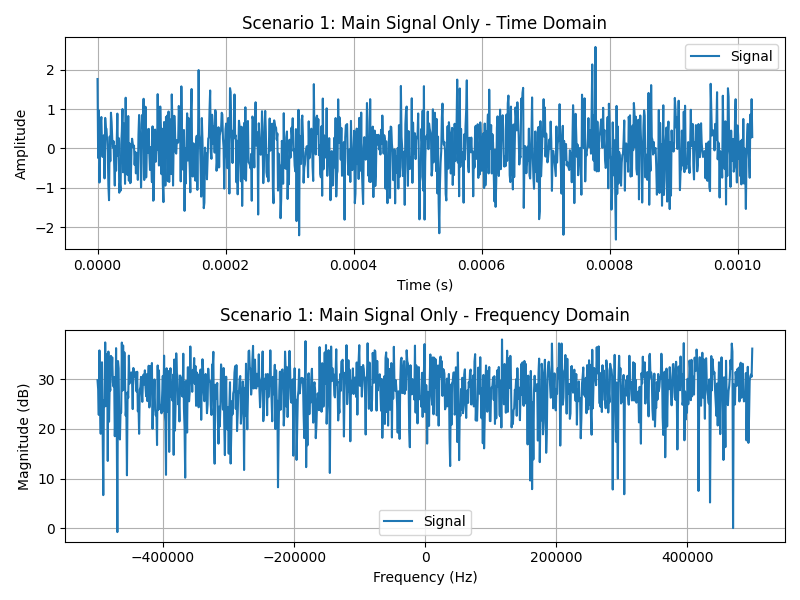

⚠️  Scenario 1: Main Signal Only: Only 1 source(s) - skipping correlation analysis


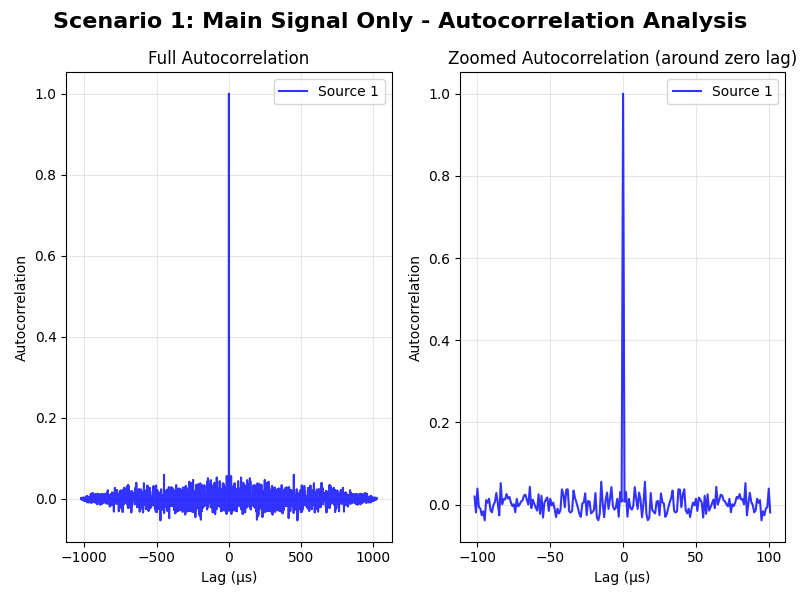


📊 Scenario 1: Main Signal Only - Statistical Summary

🎯 Source 1:
  💪 Power: 1.000000
  📐 RMS: 1.000000
  ⛰️  Peak: 2.586137
  📊 Crest Factor: 2.586
  🎵 Peak Frequency: 117.2 kHz
  🔄 Mean Phase: 0.071 rad
  📈 Phase Std: 1.816 rad
✅ Analysis complete for: Scenario 1: Main Signal Only



/Users/itamaralmog/miniconda3/envs/DOA_env/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


In [18]:
# 📊 Scenario 1: Main Signal Only (Baseline Analysis)

# Perform full analysis on the main signal only scenario
full_signal_analysis(scenarios['Main Only'], t, fs, 'Scenario 1: Main Signal Only')



🚀 Starting Full Analysis: Scenario 2: Main + 1 Interference
📊 Signal Shape: (2, 1024)


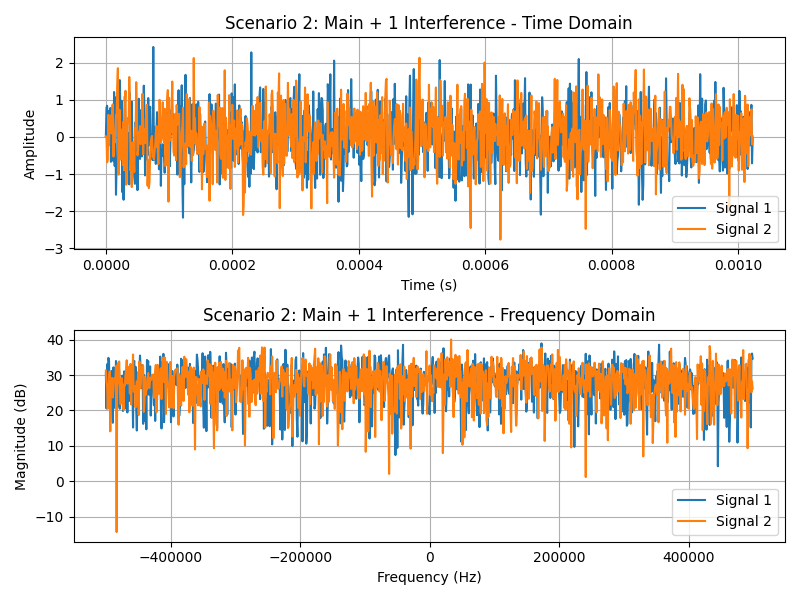

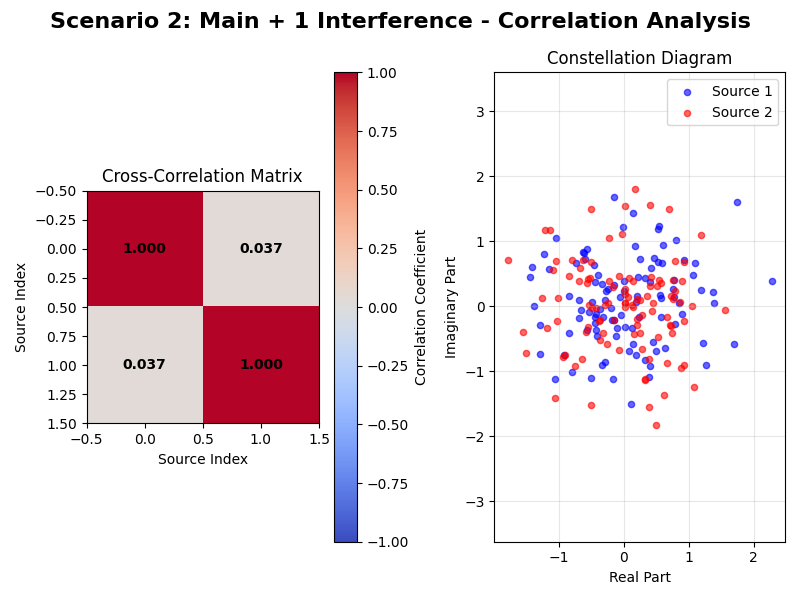

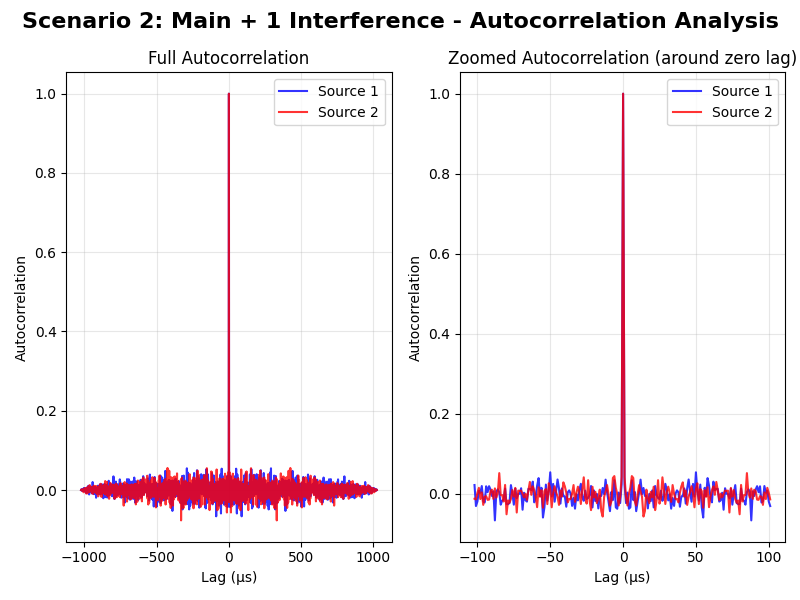


📊 Scenario 2: Main + 1 Interference - Statistical Summary

🎯 Source 1:
  💪 Power: 1.000000
  📐 RMS: 1.000000
  ⛰️  Peak: 2.561064
  📊 Crest Factor: 2.561
  🎵 Peak Frequency: 172.9 kHz
  🔄 Mean Phase: 0.007 rad
  📈 Phase Std: 1.821 rad

🎯 Source 2:
  💪 Power: 1.000000
  📐 RMS: 1.000000
  ⛰️  Peak: 3.124215
  📊 Crest Factor: 3.124
  🎵 Peak Frequency: 33.2 kHz
  🔄 Mean Phase: -0.015 rad
  📈 Phase Std: 1.759 rad

🔗 Cross-Correlation Summary:
  Source 1 ↔ Source 2: -0.0163
✅ Analysis complete for: Scenario 2: Main + 1 Interference



In [19]:
# 📊 Scenario 2: Main + 1 Interference (Interference Effects)

# Perform full analysis on the main + 1 interference scenario
full_signal_analysis(scenarios['Main + 1 Interference'], t, fs, 'Scenario 2: Main + 1 Interference')


🚀 Starting Full Analysis: Scenario 3: Main + 2 Interferences
📊 Signal Shape: (3, 1024)


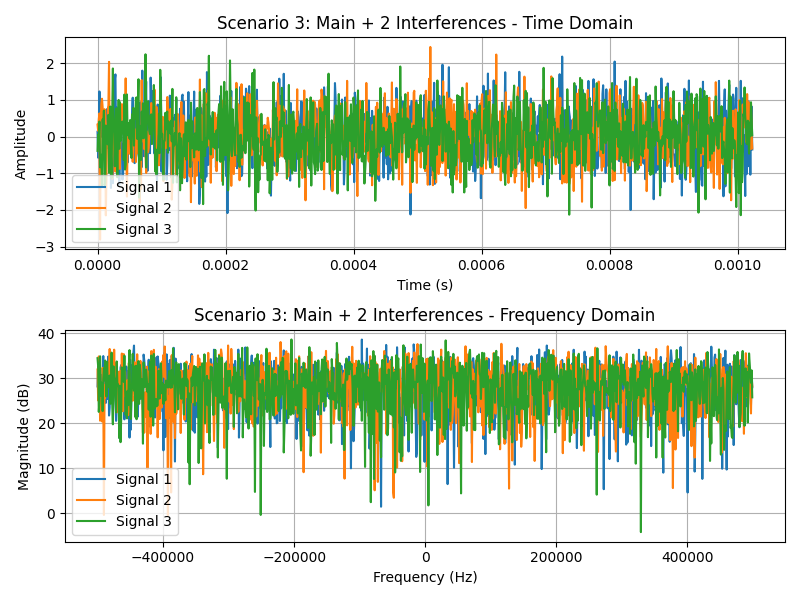

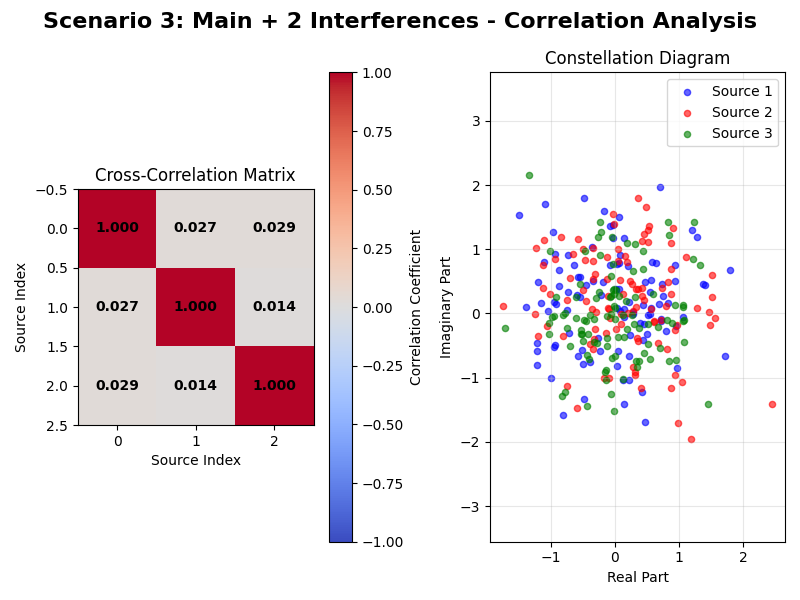

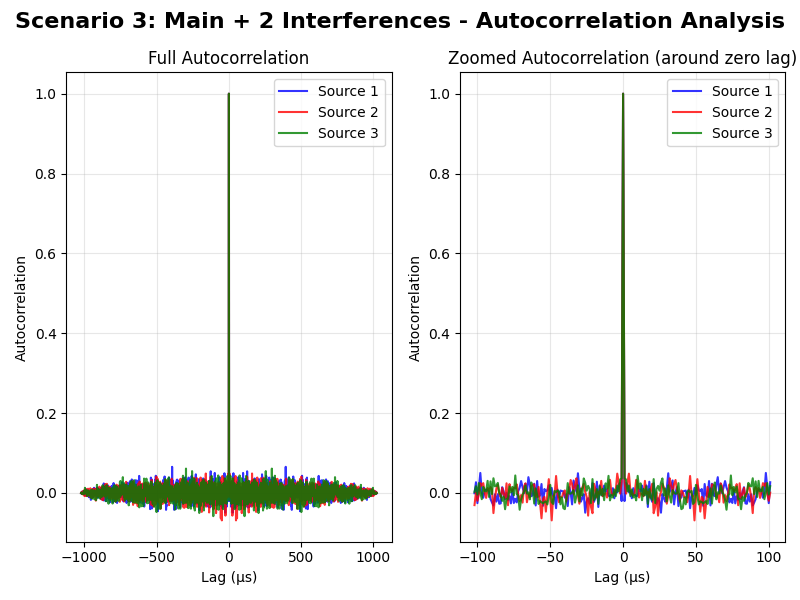


📊 Scenario 3: Main + 2 Interferences - Statistical Summary

🎯 Source 1:
  💪 Power: 1.000000
  📐 RMS: 1.000000
  ⛰️  Peak: 2.492947
  📊 Crest Factor: 2.493
  🎵 Peak Frequency: -96.7 kHz
  🔄 Mean Phase: 0.107 rad
  📈 Phase Std: 1.761 rad

🎯 Source 2:
  💪 Power: 1.000000
  📐 RMS: 1.000000
  ⛰️  Peak: 2.862387
  📊 Crest Factor: 2.862
  🎵 Peak Frequency: -220.7 kHz
  🔄 Mean Phase: 0.073 rad
  📈 Phase Std: 1.802 rad

🎯 Source 3:
  💪 Power: 1.000000
  📐 RMS: 1.000000
  ⛰️  Peak: 2.536427
  📊 Crest Factor: 2.536
  🎵 Peak Frequency: -204.1 kHz
  🔄 Mean Phase: 0.047 rad
  📈 Phase Std: 1.781 rad

🔗 Cross-Correlation Summary:
  Source 1 ↔ Source 2: -0.0148
  Source 1 ↔ Source 3: -0.0033
  Source 2 ↔ Source 3: -0.0049
✅ Analysis complete for: Scenario 3: Main + 2 Interferences



In [20]:
# 📊 Scenario 3: Main + 2 Interferences (Multiple Interference Effects)

# Perform full analysis on the main + 2 interferences scenario
full_signal_analysis(scenarios['Main + 2 Interferences'], t, fs, 'Scenario 3: Main + 2 Interferences')


🚀 Starting Full Analysis: Scenario 4: Main + 1 Multipath
📊 Signal Shape: (2, 1024)


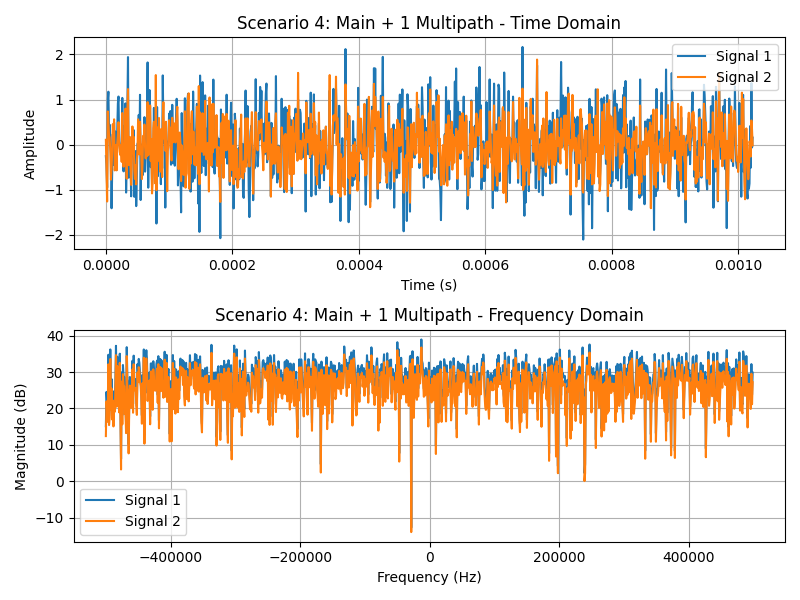

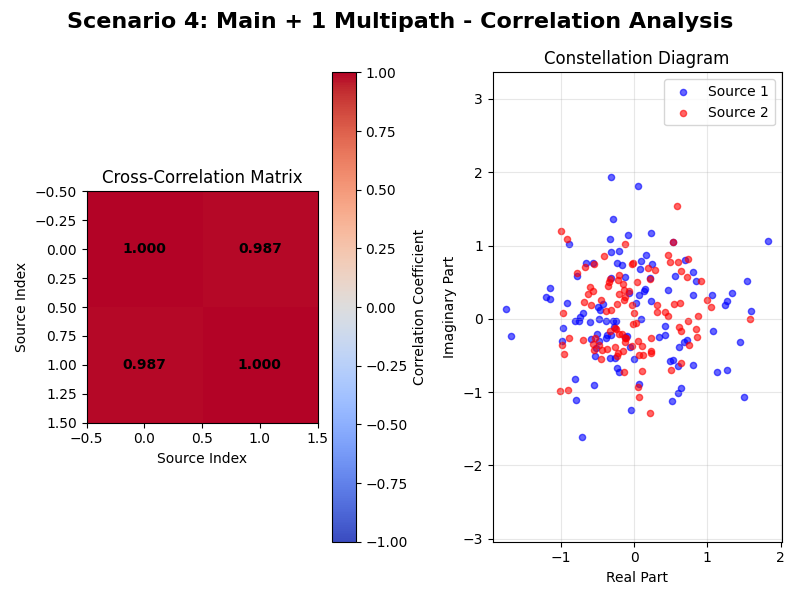

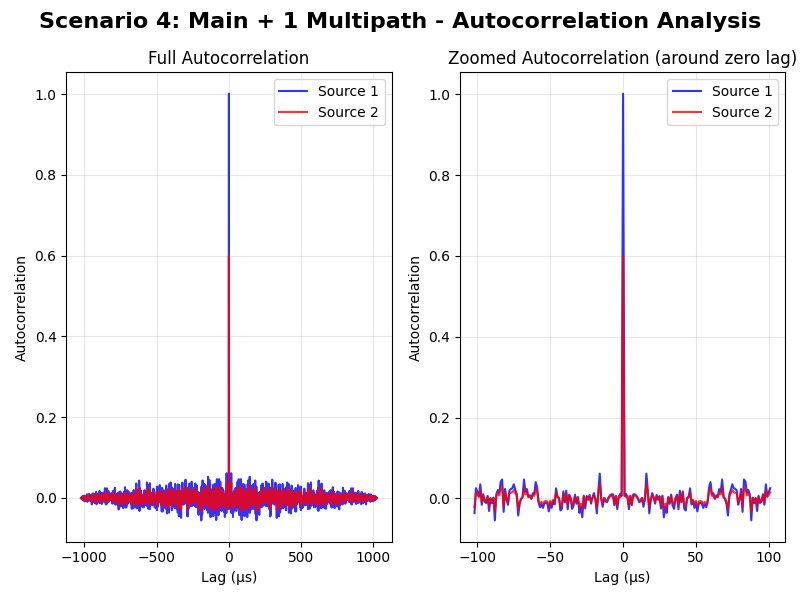


📊 Scenario 4: Main + 1 Multipath - Statistical Summary

🎯 Source 1:
  💪 Power: 1.001333
  📐 RMS: 1.000666
  ⛰️  Peak: 2.449446
  📊 Crest Factor: 2.448
  🎵 Peak Frequency: -12.7 kHz
  🔄 Mean Phase: 0.014 rad
  📈 Phase Std: 1.834 rad

🎯 Source 2:
  💪 Power: 0.600576
  📐 RMS: 0.774968
  ⛰️  Peak: 1.888587
  📊 Crest Factor: 2.437
  🎵 Peak Frequency: -12.7 kHz
  🔄 Mean Phase: 0.044 rad
  📈 Phase Std: 1.836 rad

🔗 Cross-Correlation Summary:
  Source 1 ↔ Source 2: 0.7637
✅ Analysis complete for: Scenario 4: Main + 1 Multipath



In [21]:
# 📊 Scenario 4: Main + 1 Multipath (Multipath Effects)

# Perform full analysis on the main + 1 multipath scenario
full_signal_analysis(scenarios['Main + 1 Multipath'], t, fs, 'Scenario 4: Main + 1 Multipath')


🚀 Starting Full Analysis: Scenario 5: Main + 2 Multipath
📊 Signal Shape: (3, 1024)


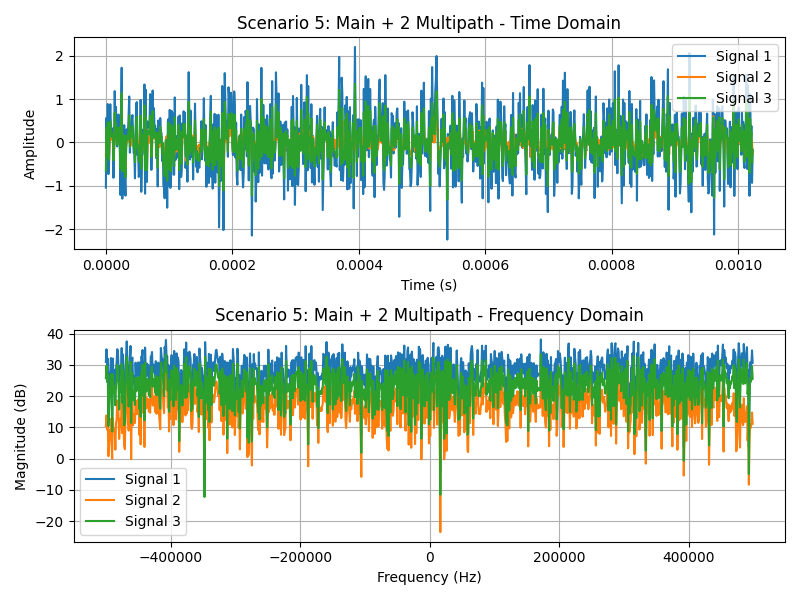

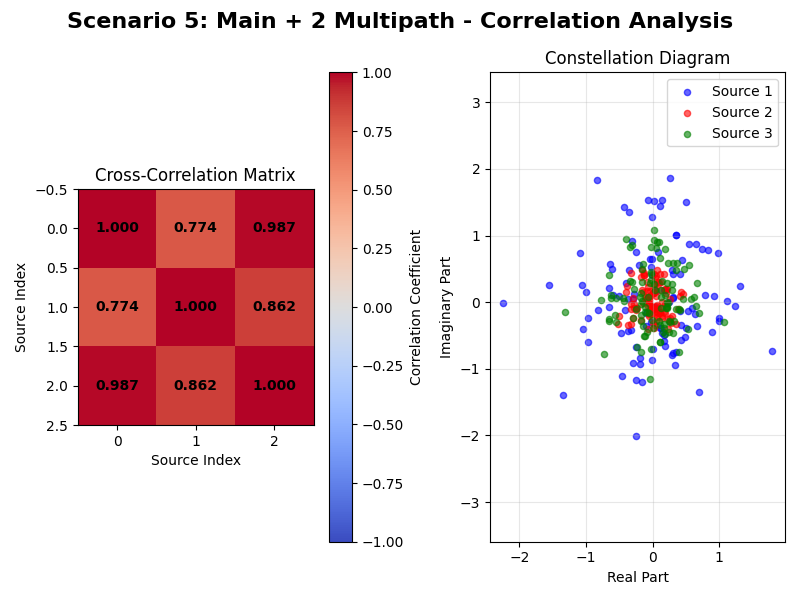

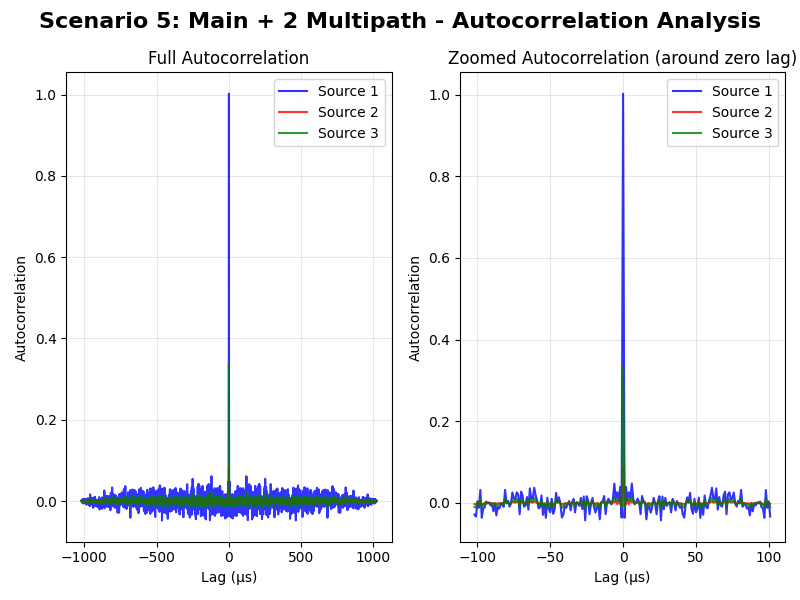


📊 Scenario 5: Main + 2 Multipath - Statistical Summary

🎯 Source 1:
  💪 Power: 1.002246
  📐 RMS: 1.001122
  ⛰️  Peak: 2.431531
  📊 Crest Factor: 2.429
  🎵 Peak Frequency: 171.9 kHz
  🔄 Mean Phase: -0.007 rad
  📈 Phase Std: 1.787 rad

🎯 Source 2:
  💪 Power: 0.085803
  📐 RMS: 0.292922
  ⛰️  Peak: 0.779694
  📊 Crest Factor: 2.662
  🎵 Peak Frequency: 171.9 kHz
  🔄 Mean Phase: -0.042 rad
  📈 Phase Std: 1.793 rad

🎯 Source 3:
  💪 Power: 0.335899
  📐 RMS: 0.579568
  ⛰️  Peak: 1.466394
  📊 Crest Factor: 2.530
  🎵 Peak Frequency: 171.9 kHz
  🔄 Mean Phase: 0.013 rad
  📈 Phase Std: 1.796 rad

🔗 Cross-Correlation Summary:
  Source 1 ↔ Source 2: 0.7354
  Source 1 ↔ Source 3: 0.9858
  Source 2 ↔ Source 3: 0.8307
✅ Analysis complete for: Scenario 5: Main + 2 Multipath



In [22]:
# 📊 Scenario 5: Main + 2 Multipath (Complex Multipath Effects)

# Perform full analysis on the main + 2 multipath scenario
full_signal_analysis(scenarios['Main + 2 Multipath'], t, fs, 'Scenario 5: Main + 2 Multipath')


🚀 Starting Full Analysis: Scenario 6: Main + 1 Interference + 1 Multipath
📊 Signal Shape: (3, 1024)


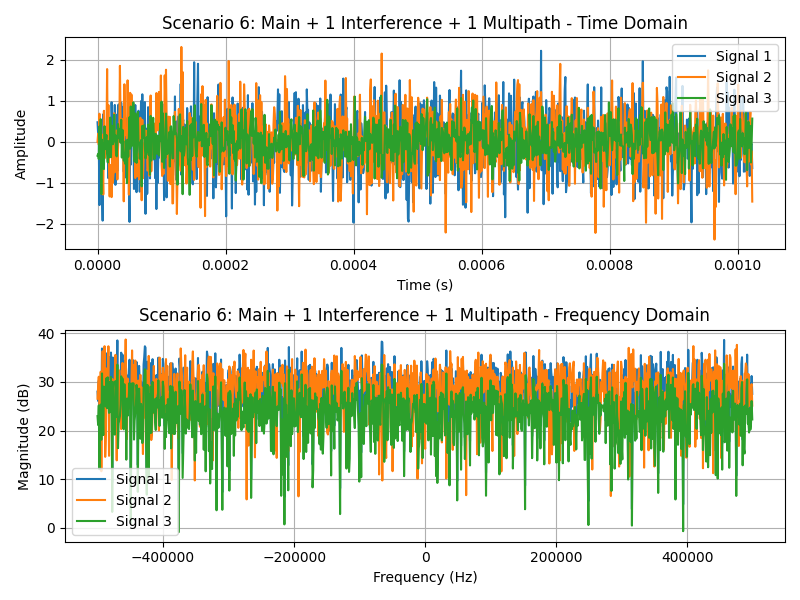

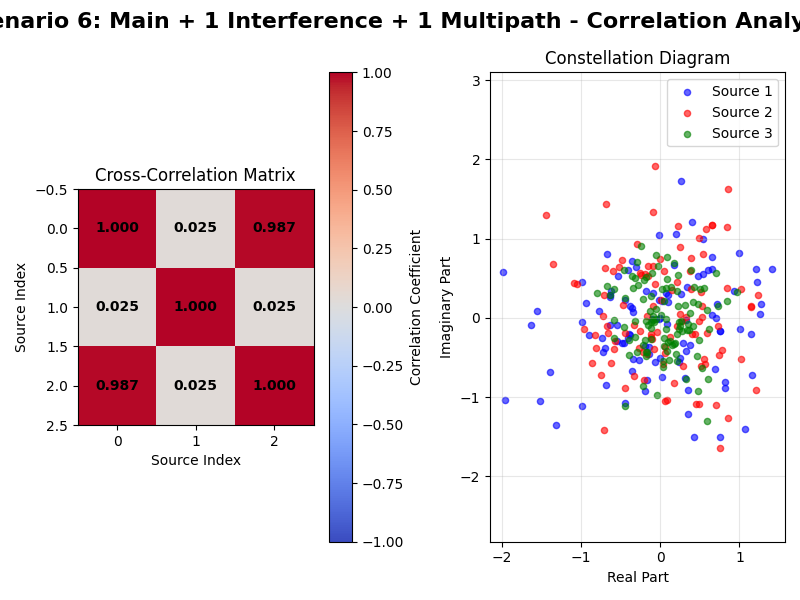

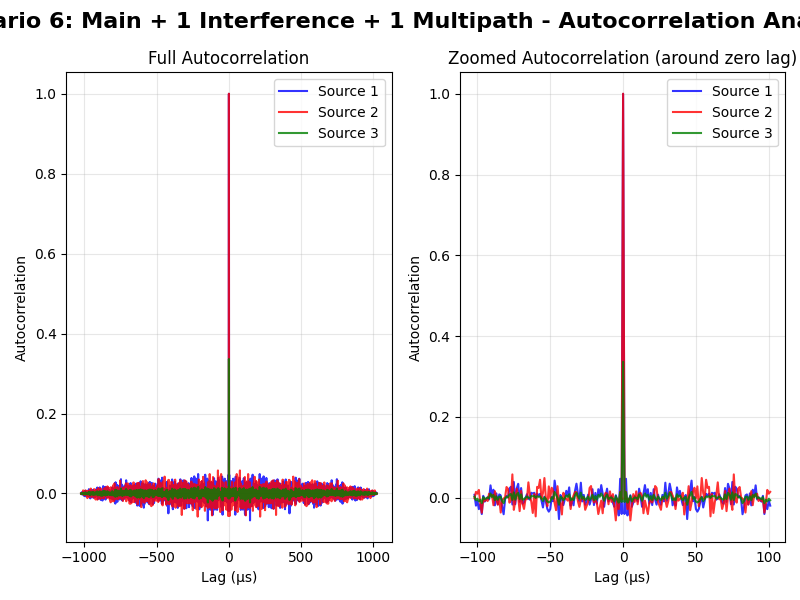


📊 Scenario 6: Main + 1 Interference + 1 Multipath - Statistical Summary

🎯 Source 1:
  💪 Power: 0.999828
  📐 RMS: 0.999914
  ⛰️  Peak: 2.386130
  📊 Crest Factor: 2.386
  🎵 Peak Frequency: 456.1 kHz
  🔄 Mean Phase: -0.055 rad
  📈 Phase Std: 1.839 rad

🎯 Source 2:
  💪 Power: 1.000291
  📐 RMS: 1.000145
  ⛰️  Peak: 2.934861
  📊 Crest Factor: 2.934
  🎵 Peak Frequency: -457.0 kHz
  🔄 Mean Phase: 0.011 rad
  📈 Phase Std: 1.818 rad

🎯 Source 3:
  💪 Power: 0.336367
  📐 RMS: 0.579972
  ⛰️  Peak: 1.442089
  📊 Crest Factor: 2.486
  🎵 Peak Frequency: 456.1 kHz
  🔄 Mean Phase: -0.045 rad
  📈 Phase Std: 1.786 rad

🔗 Cross-Correlation Summary:
  Source 1 ↔ Source 2: 0.0112
  Source 1 ↔ Source 3: 0.1013
  Source 2 ↔ Source 3: 0.0312
✅ Analysis complete for: Scenario 6: Main + 1 Interference + 1 Multipath



In [23]:
# 📊 Scenario 6: Main + 1 Interference + 1 Multipath (Combined Effects)

# Perform full analysis on the most complex scenario
full_signal_analysis(scenarios['Main + 1 Interference + 1 Multipath'], t, fs, 'Scenario 6: Main + 1 Interference + 1 Multipath')

# 🎯 Summary

This notebook demonstrates a **modular signal analysis framework** with reusable functions that can be applied to different signal scenarios.

## 🔧 Key Features

### Analysis Functions Created:
- **`analyze_time_domain()`** - Time domain visualization (real, imaginary, magnitude, phase)
- **`analyze_frequency_domain()`** - Frequency domain analysis (PSD, spectrogram)
- **`analyze_correlation()`** - Cross-correlation matrix and constellation diagrams
- **`compute_statistics()`** - Statistical summary (power, RMS, peak frequency, etc.)
- **`full_signal_analysis()`** - Complete analysis combining all functions

### Signal Scenarios Analyzed:
1. **Main Signal Only** - Baseline single source
2. **Main + 1 Interference** - Two-source interference
3. **Main + 2 Interferences** - Multiple interference sources
4. **Main + 1 Multipath** - Multipath propagation effects
5. **Main + 2 Multipath** - Complex multipath scenarios
6. **Main + 1 Interference + 1 Multipath** - Combined interference and multipath

## 🎯 Benefits of This Approach

✅ **Reusable**: Functions can be applied to any signal scenario  
✅ **Modular**: Use individual functions or complete analysis  
✅ **Comparative**: Easy to compare different scenarios  
✅ **Extensible**: Add new analysis functions as needed  
✅ **Consistent**: Standardized visualization and metrics across scenarios

## 🚀 Usage Examples

```python
# Full analysis of any scenario
full_signal_analysis(scenarios['Main + 2 Interferences'], t, fs, 'My Analysis')

# Individual analysis functions
analyze_time_domain(my_signals, t, 'My Time Analysis')
analyze_frequency_domain(my_signals, fs, 'My Frequency Analysis')
analyze_correlation(my_signals, 'My Correlation Analysis')
compute_statistics(my_signals, fs, 'My Statistics')

# Comparative analysis
for name, signals in scenarios.items():
    compute_statistics(signals, fs, f'Comparison - {name}')
```

This framework provides a solid foundation for signal analysis that can be easily extended and customized for specific research needs! 🎉
